In [1]:
import csv
import json
import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt
import re
from helpers.real_programs import get_real_programs
from helpers.dataset_generation import get_dataset, get_var_names
from helpers.gmm_distance import gmm_w2_distance

sys.path.insert(0, "../DeGAS/src")
from optimization import optimize, compile2SOGA, compile2SOGA_text, produce_cfg, produce_cfg_text, smooth_cfg, start_SOGA, initialize_params
from PROGRAMS.likelihood import compute_likelihood
import numpy as np

/home/rdoz/miniconda3/envs/myenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
program = 'if' # Options: "if", "mog1", "burglary", "csi", "easytugwar"
data_size = 50000
code = get_real_programs(program)

In [3]:
results_root = Path("../results") / program
if not results_root.exists():
    raise FileNotFoundError(f"Results folder not found: {results_root}")

best_run_dir = None
best_loss = float("inf")

for subfolder in results_root.iterdir():
    if not subfolder.is_dir():
        continue
    fitness_csv = subfolder / "best_fitness.csv"
    if not fitness_csv.exists():
        continue

    with open(fitness_csv, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        losses = [float(row["best_loss"]) for row in reader if row.get("best_loss") not in (None, "")]

    if not losses:
        continue

    run_loss = min(losses)
    if run_loss < best_loss:
        best_loss = run_loss
        best_run_dir = subfolder

if best_run_dir is None:
    raise RuntimeError(f"No valid run folders found under {results_root}")

final_candidates_path = best_run_dir / "final_candidates.json"
with open(final_candidates_path, encoding="utf-8") as f:
    final_candidates = json.load(f)

if not final_candidates:
    raise RuntimeError(f"No candidates found in {final_candidates_path}")

best_candidate = final_candidates[0]
print(best_candidate)

rewritten = best_candidate["rewritten"]
#optimized_rewritten = rewritten.replace("_params", "optimized_params")

#for each _params (like _mu1, _sigma1, etc.) in rewritten, replace it with the value in the dictionary of optimized_params[_params]

optimized_params = best_candidate.get("optimized_params", {})
#print(optimized_params)
import re

for params, value in optimized_params.items():
    if isinstance(value, str) and value.startswith("tensor"):
        value = float(value.split("(")[1].split(",")[0])

    pattern = rf"_{re.escape(params)}(?![A-Za-z0-9_])"
    rewritten = re.sub(pattern, str(value), rewritten)



print(f"Best run folder: {best_run_dir}")
print(f"Best fitness: {best_loss}")
print(rewritten)


{'id': 63, 'hypothesis': 'Nested conditional splits negative-a region into two regimes with separate mixtures.', 'structure': 'conditional_nested', 'program': 'a = gm([0.30,0.40,0.30],[-2.00,0.50,4.00],[1.20,1.80,2.70]); if a < 0.00 { if a < -1.00 { b = gm([0.50,0.50],[-0.60,0.10],[1.80,3.20]); } else { b = gm([0.35,0.25,0.40],[-0.60,0.10,3.00],[1.80,3.20,5.00]); } } else { b = gm([0.33,0.34,0.33],[5.50,7.80,9.20],[3.10,1.00,0.70]); } end if;', 'params': {'mu1': -2.0, 'mu2': 0.5, 'mu3': 4.0, 'sigma1': 1.2, 'sigma2': 1.8, 'sigma3': 2.7, 'mu4': -0.6, 'mu5': 0.1, 'sigma4': 1.8, 'sigma5': 3.2, 'mu6': -0.6, 'mu7': 0.1, 'mu8': 3.0, 'sigma6': 1.8, 'sigma7': 3.2, 'sigma8': 5.0, 'mu9': 5.5, 'mu10': 7.8, 'mu11': 9.2, 'sigma9': 3.1, 'sigma10': 1.0, 'sigma11': 0.7}, 'rewritten': 'a = gm([0.30,0.40,0.30], [_mu1, _mu2, _mu3], [_sigma1, _sigma2, _sigma3]); if a < 0.00 { if a < -1.00 { b = gm([0.50,0.50], [_mu4, _mu5], [_sigma4, _sigma5]); } else { b = gm([0.35,0.25,0.40], [_mu6, _mu7, _mu8], [_sigma6

In [4]:
print(best_candidate["optimized_params"])

{'mu1': 'tensor(-1.1189, requires_grad=True)', 'mu2': 'tensor(0.8937, requires_grad=True)', 'mu3': 'tensor(3.0942, requires_grad=True)', 'sigma1': 'tensor(1.3304, requires_grad=True)', 'sigma2': 'tensor(1.0295, requires_grad=True)', 'sigma3': 'tensor(1.4645, requires_grad=True)', 'mu4': 'tensor(-2.4052, requires_grad=True)', 'mu5': 'tensor(-1.3219, requires_grad=True)', 'sigma4': 'tensor(3.2710, requires_grad=True)', 'sigma5': 'tensor(4.3470, requires_grad=True)', 'mu6': 'tensor(-1.6322, requires_grad=True)', 'mu7': 'tensor(-1.6225, requires_grad=True)', 'mu8': 'tensor(0.5445, requires_grad=True)', 'sigma6': 'tensor(1.0101, requires_grad=True)', 'sigma7': 'tensor(1.0696, requires_grad=True)', 'sigma8': 'tensor(2.2074, requires_grad=True)', 'mu9': 'tensor(7.4264, requires_grad=True)', 'mu10': 'tensor(7.9047, requires_grad=True)', 'mu11': 'tensor(8.6556, requires_grad=True)', 'sigma9': 'tensor(0.9422, requires_grad=True)', 'sigma10': 'tensor(0.6574, requires_grad=True)', 'sigma11': 'tens

In [5]:
data = get_dataset(program, data_size)

#evaluate the synthesized program on the dataset
compiled_file = compile2SOGA_text(rewritten)
cfg = produce_cfg_text(compiled_file)
smooth_cfg(cfg)

#params_dict = initialize_params(best_candidate["optimized_params"])
loss = lambda output_dist: -compute_likelihood(output_dist, get_var_names(program), data)

output_dist = start_SOGA(cfg)
print(loss(output_dist))

real_program = get_real_programs(program)
compiled_real_program = compile2SOGA_text(real_program)
print(f"Real program: {real_program}")
cfg_real_program = produce_cfg_text(compiled_real_program)
smooth_cfg(cfg_real_program)
output_dist_real_program = start_SOGA(cfg_real_program)
print(loss(output_dist_real_program))    


line 1:256 mismatched input '}' expecting 'end if'


tensor(3.9718)
Real program: 
        a = gm([1],[1.],[2.]);
        if a < 0 {
            b = 3 * a + gm([1],[0.],[1.]);
        } else {
            b = gm([1],[8.],[1.]);  
        } end if;
        
tensor(3.6903)


In [6]:
#compute the GW2 distance (Delon & Desolneux, 2019) between the two output GMMs,
#i.e. how far the synthesized program's output distribution is from the real program's,
#as a distribution-level complement to the likelihood-based metric above
#see https://github.com/judelo/gmmot
gmm_distance = gmm_w2_distance(output_dist_real_program.gm, output_dist.gm)
print(f"GW2 distance between real and synthesized program output distributions: {gmm_distance}")

GW2 distance between real and synthesized program output distributions: 4.955886581039059


In [7]:
#compute relative log likelihood of the synthesized program with respect to the real program
relative_log_likelihood = (np.abs(loss(output_dist)) - np.abs(loss(output_dist_real_program)))/np.abs(loss(output_dist_real_program))
print(f"Relative log likelihood of the synthesized program with respect to the real program: {relative_log_likelihood}")

Relative log likelihood of the synthesized program with respect to the real program: 0.07628263634238906


/tmp/ipykernel_537551/1920567766.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  relative_log_likelihood = (np.abs(loss(output_dist)) - np.abs(loss(output_dist_real_program)))/np.abs(loss(output_dist_real_program))


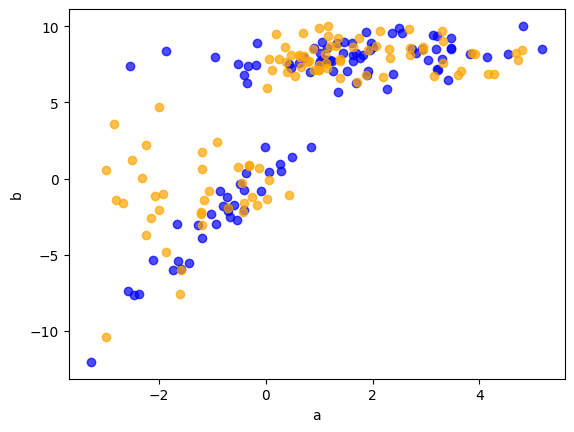

In [8]:
torch.set_default_dtype(torch.float64)
real_samples = output_dist_real_program.gm.sample(100)
synthesized_samples = output_dist.gm.sample(100)
var1 = 0
var2 = 1
#plt.figure(figsize=(12, 6))
plt.scatter(real_samples[:, var1], real_samples[:, var2], alpha=0.7, label='Real Program Samples', color='blue')
plt.scatter(synthesized_samples[:, var1], synthesized_samples[:, var2], alpha=0.7, label='Synthesized Program Samples', color='orange')
plt.xlabel(get_var_names(program)[var1])
plt.ylabel(get_var_names(program)[var2])
plt.show()  


## Compare against the RefineStat-DeGAS baseline

Loads the best run from `results/<program>/refinestat/` (produced by `python -m src.refinestat_degas.main`), substitutes its optimized parameters the same way cell 2 does above, and scores it against the same ground-truth program and metric already computed for "your method" in the cells above.

In [9]:
refinestat_root = Path("../results") / program / "refinestat"
refinestat_run_dir = None
refinestat_best_loss = float("inf")

if refinestat_root.exists():
    for subfolder in refinestat_root.iterdir():
        if not subfolder.is_dir():
            continue
        fitness_csv = subfolder / "best_fitness.csv"
        if not fitness_csv.exists():
            continue
        with open(fitness_csv, newline="", encoding="utf-8") as f:
            reader = csv.DictReader(f)
            losses = [float(row["best_loss"]) for row in reader if row.get("best_loss") not in (None, "")]
        if not losses:
            continue
        run_loss = min(losses)
        if run_loss < refinestat_best_loss:
            refinestat_best_loss = run_loss
            refinestat_run_dir = subfolder

if refinestat_run_dir is None:
    print(f"No RefineStat-DeGAS runs found under {refinestat_root} -- run "
          f"`python -m src.refinestat_degas.main --programs {program}` first.")
else:
    with open(refinestat_run_dir / "final_candidates.json", encoding="utf-8") as f:
        refinestat_candidates = json.load(f)
    if not refinestat_candidates:
        print(f"{refinestat_run_dir} has no valid candidate (refine loop never hit its K threshold).")
        refinestat_run_dir = None
    else:
        refinestat_best = refinestat_candidates[0]
        refinestat_rewritten = refinestat_best["rewritten"]
        for pname, value in refinestat_best["optimized_params"].items():
            pattern = rf"_{re.escape(pname)}(?![A-Za-z0-9_])"
            refinestat_rewritten = re.sub(pattern, str(value), refinestat_rewritten)
        print(f"Best RefineStat-DeGAS run: {refinestat_run_dir}")
        print(refinestat_rewritten)


Best RefineStat-DeGAS run: ../results/if/refinestat/20260805_183520_seed2
a = gm([0.50, 0.50], [1.0273761152157808, 1.0273761152157808], [1.61423687909473, 1.61423687909473]) ; b = gm([0.30, 0.70], [3.0403860514588175, 7.137088416625489], [5.813434149475493, 1.6673593061104792]) ;


In [10]:
if refinestat_run_dir is not None:
    refinestat_compiled = compile2SOGA_text(refinestat_rewritten)
    refinestat_cfg = produce_cfg_text(refinestat_compiled)
    smooth_cfg(refinestat_cfg)
    refinestat_output_dist = start_SOGA(refinestat_cfg)

    refinestat_loss_val = loss(refinestat_output_dist)
    refinestat_relative_ll = (
        np.abs(refinestat_loss_val) - np.abs(loss(output_dist_real_program))
    ) / np.abs(loss(output_dist_real_program))

    print(f"Your method       -- NLL: {loss(output_dist):.4f}  "
          f"relative log-likelihood vs ground truth: {relative_log_likelihood:.4f}")
    print(f"RefineStat-DeGAS  -- NLL: {refinestat_loss_val:.4f}  "
          f"relative log-likelihood vs ground truth: {refinestat_relative_ll:.4f}")


Your method       -- NLL: 3.9718  relative log-likelihood vs ground truth: 0.0763
RefineStat-DeGAS  -- NLL: 4.9831  relative log-likelihood vs ground truth: 0.3503


/tmp/ipykernel_537551/2134473763.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.abs(refinestat_loss_val) - np.abs(loss(output_dist_real_program))
/tmp/ipykernel_537551/2134473763.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ) / np.abs(loss(output_dist_real_program))


## Compare against the RefineStat-DeGAS-MCMC baseline

Same idea as the cells above, but loading `results/<program>/refinestat_mcmc/` (produced by `python -m src.refinestat_degas.main --inference mcmc`) -- genuine NUTS/MCMC posterior inference via Pyro (see `src/refinestat_degas/mcmc_diagnostics.py` and `pyro_model.py`), as opposed to the gradient-optimized point estimate used by both "your method" and the `refinestat` (gradient) baseline above. Substitutes the posterior *mean* parameters (`posterior_mean_params`) into the candidate's rewritten program the same way, for a like-for-like scoring against the ground-truth program.

In [11]:
refinestat_mcmc_root = Path("../results") / program / "refinestat_mcmc"
refinestat_mcmc_run_dir = None
refinestat_mcmc_best_loss = float("inf")

if refinestat_mcmc_root.exists():
    for subfolder in refinestat_mcmc_root.iterdir():
        if not subfolder.is_dir():
            continue
        fitness_csv = subfolder / "best_fitness.csv"
        if not fitness_csv.exists():
            continue
        with open(fitness_csv, newline="", encoding="utf-8") as f:
            reader = csv.DictReader(f)
            losses = [float(row["best_loss"]) for row in reader if row.get("best_loss") not in (None, "")]
        if not losses:
            continue
        run_loss = min(losses)
        if run_loss < refinestat_mcmc_best_loss:
            refinestat_mcmc_best_loss = run_loss
            refinestat_mcmc_run_dir = subfolder

if refinestat_mcmc_run_dir is None:
    print(f"No RefineStat-DeGAS-MCMC runs found under {refinestat_mcmc_root} -- run "
          f"`python -m src.refinestat_degas.main --inference mcmc --programs {program}` first.")
else:
    with open(refinestat_mcmc_run_dir / "final_candidates.json", encoding="utf-8") as f:
        refinestat_mcmc_candidates = json.load(f)
    if not refinestat_mcmc_candidates:
        print(f"{refinestat_mcmc_run_dir} has no valid candidate (refine loop never hit its K threshold).")
        refinestat_mcmc_run_dir = None
    else:
        refinestat_mcmc_best = refinestat_mcmc_candidates[0]
        refinestat_mcmc_rewritten = refinestat_mcmc_best["rewritten"]
        for pname, value in refinestat_mcmc_best["posterior_mean_params"].items():
            pattern = rf"_{re.escape(pname)}(?![A-Za-z0-9_])"
            refinestat_mcmc_rewritten = re.sub(pattern, str(value), refinestat_mcmc_rewritten)
        print(f"Best RefineStat-DeGAS-MCMC run: {refinestat_mcmc_run_dir}")
        print(f"Diagnostics: max_r_hat={refinestat_mcmc_best.get('max_r_hat'):.3f}  "
              f"elpd_loo={refinestat_mcmc_best.get('elpd_loo'):.3f}  "
              f"pareto_k_high_frac={refinestat_mcmc_best.get('pareto_k_high_frac'):.3f}")
        print(refinestat_mcmc_rewritten)


Best RefineStat-DeGAS-MCMC run: ../results/if/refinestat_mcmc/20260805_193015_seed5
Diagnostics: max_r_hat=1.010  elpd_loo=-3636.854  pareto_k_high_frac=0.000
a = gm([0.50, 0.50], [0.9832449807395506, 0.9492730589275206], [1.8737634151431852, 1.8700220634788938]) ; b = gm([0.50, 0.50], [-3.5763599765614473, 8.018113375395995], [3.3181545603523426, 1.0090123951393821]) ;


In [12]:
if refinestat_mcmc_run_dir is not None:
    refinestat_mcmc_compiled = compile2SOGA_text(refinestat_mcmc_rewritten)
    refinestat_mcmc_cfg = produce_cfg_text(refinestat_mcmc_compiled)
    smooth_cfg(refinestat_mcmc_cfg)
    refinestat_mcmc_output_dist = start_SOGA(refinestat_mcmc_cfg)

    refinestat_mcmc_loss_val = loss(refinestat_mcmc_output_dist)
    refinestat_mcmc_relative_ll = (
        np.abs(refinestat_mcmc_loss_val) - np.abs(loss(output_dist_real_program))
    ) / np.abs(loss(output_dist_real_program))

    print(f"Your method            -- NLL: {loss(output_dist):.4f}  "
          f"relative log-likelihood vs ground truth: {relative_log_likelihood:.4f}")
    if refinestat_run_dir is not None:
        print(f"RefineStat-DeGAS (grad) -- NLL: {refinestat_loss_val:.4f}  "
              f"relative log-likelihood vs ground truth: {refinestat_relative_ll:.4f}")
    print(f"RefineStat-DeGAS (MCMC) -- NLL: {refinestat_mcmc_loss_val:.4f}  "
          f"relative log-likelihood vs ground truth: {refinestat_mcmc_relative_ll:.4f}")


/tmp/ipykernel_537551/752678635.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.abs(refinestat_mcmc_loss_val) - np.abs(loss(output_dist_real_program))


Your method            -- NLL: 3.9718  relative log-likelihood vs ground truth: 0.0763
RefineStat-DeGAS (grad) -- NLL: 4.9831  relative log-likelihood vs ground truth: 0.3503
RefineStat-DeGAS (MCMC) -- NLL: 4.5805  relative log-likelihood vs ground truth: 0.2412


/tmp/ipykernel_537551/752678635.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ) / np.abs(loss(output_dist_real_program))
